# py-dynbenchmark walkthrough

Full end-to-end demonstration: build a synthetic dataset → score a method → run the cross-method benchmark.

## 1. Setup

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path('..').resolve()))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import pydynbenchmark as pyb
print(f'pydynbenchmark {pyb.__version__}')

pydynbenchmark 0.1.0


## 2. Generate synthetic datasets

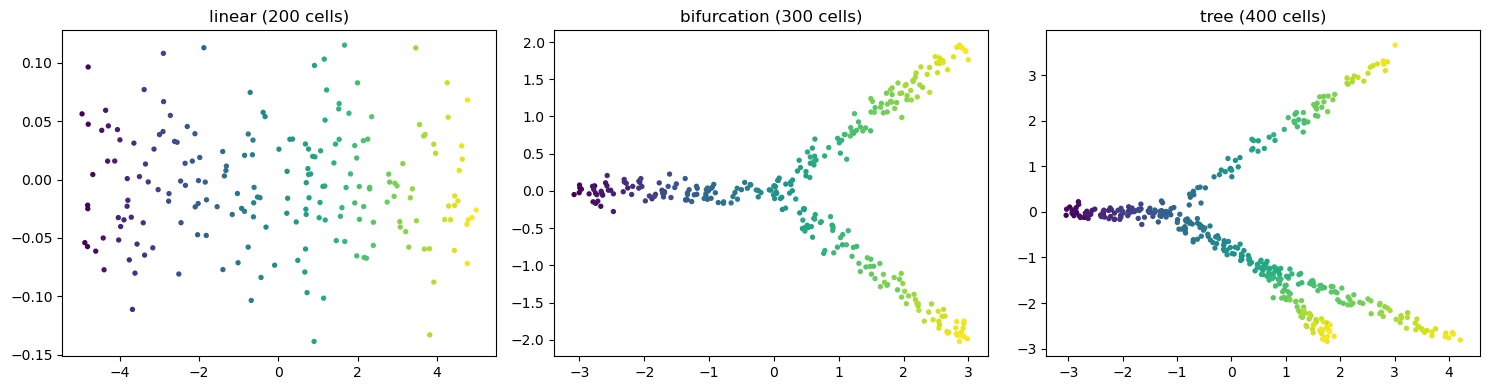

In [2]:
ds_linear = pyb.generate_linear(n_cells=200, n_genes=100, seed=0)
ds_bif    = pyb.generate_bifurcation(n_cells=300, n_genes=100, seed=0)
ds_tree   = pyb.generate_tree(n_cells=400, n_genes=120, seed=0)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, ds, title in zip(axes, [ds_linear, ds_bif, ds_tree],
                         ['linear', 'bifurcation', 'tree']):
    ax.scatter(ds.embedding[:,0], ds.embedding[:,1], c=ds.pseudotime, s=8, cmap='viridis')
    ax.set_title(f'{title} ({ds.counts.shape[0]} cells)')
plt.tight_layout(); plt.show()

## 3. Metric demos

### 3.1 cor_dist on perfect prediction

In [3]:
rho = pyb.cor_dist(ds_linear.pseudotime, ds_linear.branch,
                   ds_linear.pseudotime, ds_linear.branch)
print(f'cor_dist (perfect):   {rho:.3f}')

shuffled = np.random.RandomState(0).permutation(ds_linear.pseudotime)
rho_bad = pyb.cor_dist(ds_linear.pseudotime, ds_linear.branch,
                       shuffled, ds_linear.branch)
print(f'cor_dist (shuffled): {rho_bad:.3f}')

cor_dist (perfect):   1.000
cor_dist (shuffled): 0.000


### 3.2 F1_branches

In [4]:
f1_perfect = pyb.f1_branches(ds_bif.branch, ds_bif.branch)
print(f'F1_branches (perfect): {f1_perfect:.3f}')
# Random labels
random_b = np.random.RandomState(0).choice(np.unique(ds_bif.branch), size=len(ds_bif.branch))
print(f'F1_branches (random): {pyb.f1_branches(ds_bif.branch, random_b):.3f}')

F1_branches (perfect): 1.000
F1_branches (random): 0.386


### 3.3 wcor_features

In [5]:
ratio = pyb.wcor_features(ds_linear.counts, ds_linear.pseudotime, ds_linear.pseudotime)
print(f'wcor_features (perfect): {ratio:.3f}')

wcor_features (perfect): 0.835


## 4. Define a method and benchmark it

In [6]:
import sys as _sys
_sys.path.insert(0, str(Path('..').resolve().parent / 'py-SCORPIUS'))
import pyscorpius

def scorpius_adapter(ds):
    space = pyscorpius.reduce_dimensionality(ds.counts, ndim=3)
    traj = pyscorpius.infer_trajectory(space)
    return {'pseudotime': traj['time']}

result = pyb.run_benchmark(
    methods={'pySCORPIUS': scorpius_adapter},
    datasets=['linear_200', 'bifurcation_300'],
    verbose=True,
)
print(result.to_dataframe())

  ✓ pySCORPIUS         on linear_200         [  0.3s]: cor_dist=0.868, wcor_features=0.813, overall=0.840


  ✓ pySCORPIUS         on bifurcation_300    [  0.5s]: cor_dist=0.474, wcor_features=0.657, overall=0.558
       method          dataset  cor_dist  wcor_features   overall error  \
0  pySCORPIUS       linear_200  0.867679       0.812799  0.839792  None   
1  pySCORPIUS  bifurcation_300  0.474139       0.656923  0.558098  None   

   runtime_s  
0   0.275112  
1   0.547904  


## 5. Summary across datasets

In [7]:
print(result.summary().round(3))

            cor_dist  wcor_features  overall
method                                      
pySCORPIUS     0.671          0.735    0.699


## 6. Multi-method benchmark — see `benchmark_traj_ports.py`

The full benchmark across all 7 trajectory ports (pySCORPIUS, pyTSCAN, pySlingshot, pydestiny, pyURD, pyCytoTRACE, pyMonocle3) is in `examples/benchmark_traj_ports.py`. Run it via::

    python examples/benchmark_traj_ports.py

Results are committed to `examples/benchmark_results.csv` and `examples/benchmark_summary.csv`, and visualised in `examples/benchmark_summary.png`.

## 7. Metric definitions

- **HIM**: ½·(Hamming + Ipsen-Mikhailov) on milestone-graph adjacencies. Captures topology.
- **F1_branches**: macro F1 of cell-to-branch assignment after Hungarian label-matching.
- **cor_dist**: Pearson r between gold and predicted cell-cell geodesic distance matrices. Captures pseudotime + topology.
- **wcor_features**: |Pearson r| of top-20 gold-DE genes vs predicted pseudotime.
- **overall**: geometric mean of the available metrics.

All values in [0, 1], higher is better.